# Text Classification

* * *

In the previous tutorial, we used *unsupervised* methods (KMeans, HDBSCAN, LDA, BERTopic) to discover groups in the CFPB complaint corpus without using the `Product` labels. In this tutorial, we switch to *supervised* learning: we tell the model what the right answer is on a training set, and ask it to predict the label on a held-out test set.

We will use the same four product categories — `Mortgage`, `Credit card or prepaid card`, `Debt collection`, `Student loan` — and try to predict `Product` from the complaint narrative and metadata.

This tutorial covers:

1. The basic building blocks of a classification pipeline — splitting data, training, evaluating, comparing models.
2. Feature engineering — we will build several different feature sets out of the same data and see how each one affects accuracy:
    - non-text metadata (e.g., `State`, `Submitted via`)
    - engineered text features (length, word count, sentiment)
    - tf-idf vectors
    - top 25 n-grams
    - combinations of the above
3. Three families of classifiers:
    - Logistic Regression — linear, fast, very interpretable
    - Support Vector Machine — margin-based, strong baseline on text
    - Multi-Layer Perceptron — a simple neural network

We'll see how much of the accuracy comes from the *features* you give the model versus the *algorithm* you pick. Often the answer is humbling: the features matter more.

Adapted from:
- https://github.com/dlab-berkeley/Computational-Social-Science-Training-Program


# Setup

In [1]:
# download libraries (uncomment if running fresh)
# !pip install scikit-learn
# !pip install textblob
# !pip install spacy
# !python -m spacy download en_core_web_sm

In [2]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_context("talk")

# Load data

Same stratified sample of 4,000 complaints (1,000 per product) used in the clustering tutorial.

In [3]:
import gdown

file_id = '1VwrbAod_L2rdxw_LnWhS4ogQh_BChmum'
output_filename = 'cfpb_sample.csv'

if file_id and not os.path.exists(output_filename):
    gdown.download(id=file_id, output=output_filename, quiet=False)
    print(f"File '{output_filename}' downloaded successfully!")
else:
    print(f"Using existing file '{output_filename}'.")

cfpb = pd.read_csv(output_filename)
print(cfpb.shape)
cfpb['Product'].value_counts()


Using existing file 'cfpb_sample.csv'.
(4000, 18)


Product
Credit card or prepaid card    1000
Debt collection                1000
Mortgage                       1000
Student loan                   1000
Name: count, dtype: int64

# Preprocess text

We reuse the same cleaning function from the clustering tutorial. The result is a `text_clean` column that holds the normalized narrative — lowercased, redacted tokens (`XXXX`) removed, digits replaced with `DIGIT`, punctuation stripped, stop words removed.

In [4]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS
from string import punctuation

def text_cleaning(text):
    stop_words = STOP_WORDS
    punc = set(punctuation) - {'.', '?', '!'}

    text = text.lower()
    text = re.sub(r'\b[Xx]{2,}\b', '', text)         # remove redactions
    text = re.sub(r'\d+', 'DIGIT', text)              # numbers → placeholder
    text = "".join(ch if ch not in punc else ' ' for ch in text)
    text = ' '.join(w for w in text.split() if w not in stop_words)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

cfpb['text_clean'] = cfpb['Consumer complaint narrative'].map(text_cleaning)
cfpb['text_clean'].head()


0    vacation DIGIT . gone mail box broken mail sto...
1    hello unused visa value dollars. expired. cont...
2    signed aadvantage mastercards issued citibank ...
3    ordered shoes small store price good true caus...
4    commenity bank. DIGIT interest loan needed pai...
Name: text_clean, dtype: str

# Supervised learning basics

Before we start building features, let's nail down the vocabulary.

| Concept | What it means here |
|---|---|
| label / target (`y`) | the `Product` column — what we want to predict |
| features (`X`) | one or more columns we use as input to the model |
| training set | the rows the model is allowed to learn from |
| test set | held-out rows the model has never seen — used to measure generalization |
| classifier | an algorithm that maps features `X` → predicted label `y_hat` |
| accuracy | fraction of test rows where `y_hat == y` |

## Why a train/test split?

If we evaluate a model on the *same* rows it was trained on, the score tells us how well it *memorized*, not how well it *generalizes*. Splitting the data into a training set (e.g., 80%) and a test set (e.g., 20%) gives us an honest estimate of how the model will perform on new complaints it has never seen.


**Note:** A single train/test split gives you *one accuracy number.* But that number depends on which 800 rows happened to land in the test set — if you re-ran with a different `random_state`, the accuracy could shift by 1-3 percentage points just from sampling noise.

<img src='./images/cv.png' alt="cv" width="600">

The standard tool is k-fold cross-validation:

1. Shuffle the data and split it into `k` equal folds (typically 5 or 10).
2. For each fold `i`: train on the other `k-1` folds, evaluate on fold `i`.
3. Report the mean ± standard deviation of the `k` accuracies.

`sklearn` has an one-liner code that does "fit and evaluate 5 times"
``` python
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
```

Reference:
- [sklearn cross-validation guide](https://scikit-learn.org/stable/modules/cross_validation.html)


## Encoding the label

Most classifiers expect the target as integers or a numeric array, not as the raw string `"Mortgage"`. We use `LabelEncoder` to map the four product names to `{0, 1, 2, 3}`. We keep the mapping around so we can decode predictions back to readable names later.

In [5]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
cfpb['y'] = le.fit_transform(cfpb['Product'])

print("Label mapping:")
for i, name in enumerate(le.classes_):
    print(f"  {i} → {name}")


Label mapping:
  0 → Credit card or prepaid card
  1 → Debt collection
  2 → Mortgage
  3 → Student loan


## Make the train/test split

We split *once*, at the row level, and use the same split for every feature set / model combination below. 


In [6]:
from sklearn.model_selection import train_test_split

# Indices, not the feature matrix — we'll subset each feature set by these indices.
train_idx, test_idx = train_test_split(
    cfpb.index,
    test_size=0.2,
    stratify=cfpb['y'],     # keep class balance in both splits
    random_state=42,
)

y_train = cfpb.loc[train_idx, 'y'].values
y_test  = cfpb.loc[test_idx,  'y'].values

print(f"Train: {len(train_idx)}  Test: {len(test_idx)}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test  class balance: {np.bincount(y_test)}")


Train: 3200  Test: 800
Train class balance: [800 800 800 800]
Test  class balance: [200 200 200 200]


## A baseline: how good is "always guess the most common class"?

Whenever you report a classifier's accuracy, you should know what a trivial baseline would score. With four balanced classes, "always guess one class" scores 25%. Anything above that is the part that's actually doing work.

In [7]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent').fit(np.zeros((len(train_idx), 1)), y_train) # np.zeros((len(train_idx), 1)) is just a placeholder:
baseline_acc = dummy.score(np.zeros((len(test_idx), 1)), y_test)
print(f"Most-frequent-class baseline accuracy: {baseline_acc:.3f}")


Most-frequent-class baseline accuracy: 0.250


# Feature engineering

We will build five feature sets out of the same data and then run every classifier on every set. 

| # | Feature set | What's in it |
|---|---|---|
| 1 | Non-text features | metadata columns like `State`, `Submitted via`, `Timely response?` |
| 2 | Engineered text features | length, word count, sentiment polarity & subjectivity |
| 3 | Non-text + engineered text | (1) and (2) concatenated |
| 4 | Tf-idf | sparse tf-idf vector over the full vocabulary |
| 5 | Top 25 n-gram counts | counts of the 25 most frequent bi/tri-grams |



## 1. Non-text features

The CFPB dataset has plenty of structured columns that are not the complaint text. Some of these — like `Sub-product` or `Issue` — would be cheating, because they're essentially copies of the `Product` label. We pick columns that describe the *complaint process*, not the product:

- `State` — where the consumer lives
- `Submitted via` — Web, Phone, Postal mail, etc.
- `Company response to consumer` — Closed with explanation, Closed with monetary relief, etc.
- `Timely response?` — Yes / No
- `Consumer disputed?` — Yes / No / missing

These are all categorical, so we one-hot encode them.

In [29]:
non_text_cols = ['State', 'Submitted via', 'Company response to consumer',
                 'Timely response?', 'Consumer disputed?']

non_text_raw = cfpb[non_text_cols].fillna('missing').astype(str)
non_text = pd.get_dummies(non_text_raw, drop_first=False).astype(float)

print(f"Non-text features shape: {non_text.shape}")
print("Non-text features:")
for col in non_text.columns:
    print(f"  {col}")
non_text.head()


Non-text features shape: (4000, 69)
Non-text features:
  State_AE
  State_AK
  State_AL
  State_AP
  State_AR
  State_AZ
  State_CA
  State_CO
  State_CT
  State_DC
  State_DE
  State_FL
  State_GA
  State_HI
  State_IA
  State_ID
  State_IL
  State_IN
  State_KS
  State_KY
  State_LA
  State_MA
  State_MD
  State_ME
  State_MI
  State_MN
  State_MO
  State_MS
  State_MT
  State_NC
  State_ND
  State_NE
  State_NH
  State_NJ
  State_NM
  State_NV
  State_NY
  State_OH
  State_OK
  State_OR
  State_PA
  State_PR
  State_RI
  State_SC
  State_SD
  State_TN
  State_TX
  State_UNITED STATES MINOR OUTLYING ISLANDS
  State_UT
  State_VA
  State_VI
  State_VT
  State_WA
  State_WI
  State_WV
  State_WY
  State_missing
  Submitted via_Web
  Company response to consumer_Closed
  Company response to consumer_Closed with explanation
  Company response to consumer_Closed with monetary relief
  Company response to consumer_Closed with non-monetary relief
  Company response to consumer_In progress
 

,State_AE,State_AK,State_AL,State_AP,State_AR,State_AZ,State_CA,State_CO,State_CT,State_DC,...,Company response to consumer_Closed with explanation,Company response to consumer_Closed with monetary relief,Company response to consumer_Closed with non-monetary relief,Company response to consumer_In progress,Company response to consumer_Untimely response,Timely response?_No,Timely response?_Yes,Consumer disputed?_No,Consumer disputed?_Yes,Consumer disputed?_missing
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


## 2. Engineered text features

These are scalar summaries of the text — fast to compute, easy to interpret, but they throw away the actual words.

- `complaint_len` — number of characters
- `word_count`    — number of whitespace-separated tokens
- `polarity`      — TextBlob sentiment in `[-1, +1]`
- `subjectivity`  — TextBlob subjectivity in `[0, 1]`

In [9]:
from textblob import TextBlob

cfpb['complaint_len'] = cfpb['text_clean'].apply(len)
cfpb['word_count']    = cfpb['text_clean'].apply(lambda x: len(str(x).split()))
cfpb['polarity']      = cfpb['text_clean'].map(lambda t: TextBlob(t).sentiment.polarity) # 1.0 (very negative) to +1.0 (very positive), with 0.0 meaning neutral.
cfpb['subjectivity']  = cfpb['text_clean'].map(lambda t: TextBlob(t).sentiment.subjectivity) # how opinion-based vs. fact-based 

engineered = cfpb[['complaint_len', 'word_count', 'polarity', 'subjectivity']].astype(float)
engineered.head()


,complaint_len,word_count,polarity,subjectivity
0,405.0,58.0,-0.097348,0.358838
1,212.0,31.0,0.000000,0.000000
2,536.0,64.0,-0.028571,0.414286
3,138.0,20.0,0.200000,0.512500
4,176.0,27.0,0.000000,0.562500


A quick look at these features by class. If the distributions overlap completely, the feature carries no signal for classification.

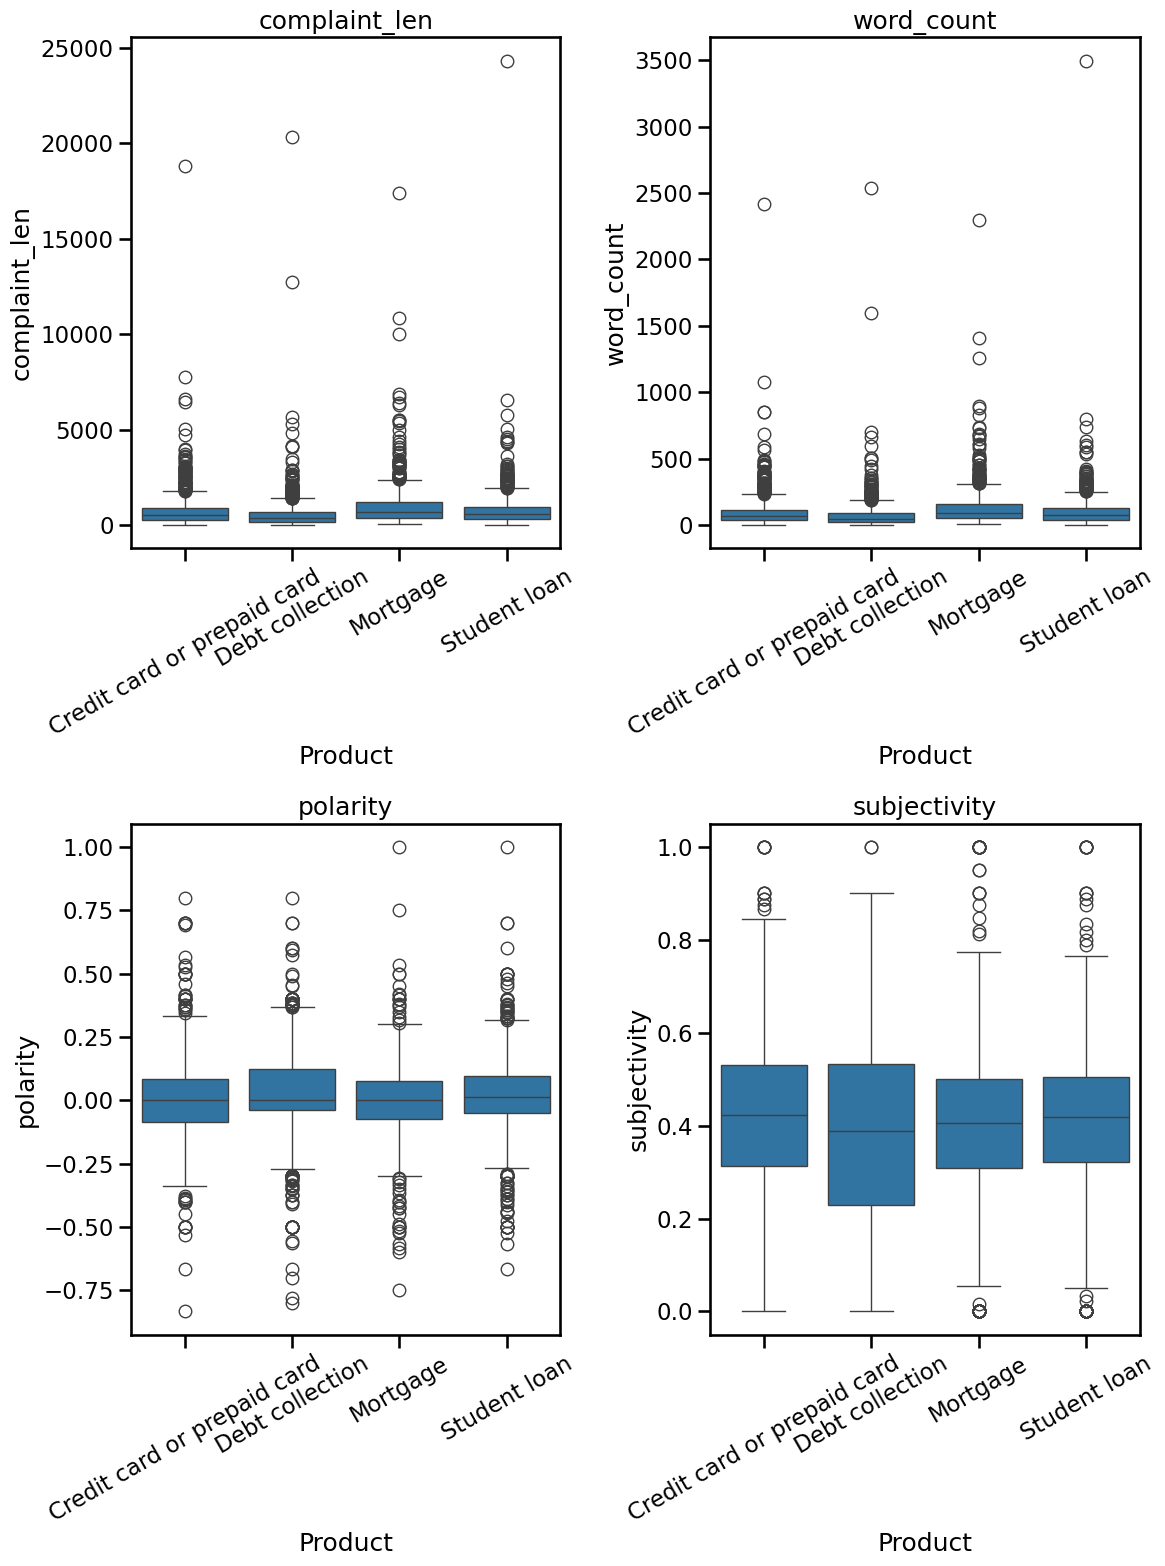

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 16))
for ax, col in zip(axes.flat, engineered.columns):
    sns.boxplot(data=cfpb, x='Product', y=col, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


## 3. Non-text + engineered text

Concatenate the two dense feature sets side by side.

In [11]:
non_text_plus_engineered = pd.concat(
    [non_text.reset_index(drop=True), engineered.reset_index(drop=True)],
    axis=1,
)
non_text_plus_engineered.index = cfpb.index   # preserve original index for splitting
print(f"Shape: {non_text_plus_engineered.shape}")


Shape: (4000, 73)


## 4. Tf-idf features

This is the same vectorizer we used in the clustering tutorial. The output is a sparse matrix with one row per document and one column per vocabulary term. Each value is the term's tf-idf weight in that document.

**Caution:** We fit vectorizer on the **training rows only**, then transform both train and test. This is the cleanest way to avoid leakage when the vectorizer learns vocabulary statistics from the data.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import csr_matrix

tfidf_vec = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    min_df=2,
    max_df=0.95,
)

X_tfidf_train = tfidf_vec.fit_transform(cfpb.loc[train_idx, 'text_clean'])
X_tfidf_test  = tfidf_vec.transform(cfpb.loc[test_idx,  'text_clean'])

print(f"Train tf-idf shape: {X_tfidf_train.shape}")
print(f"Test  tf-idf shape: {X_tfidf_test.shape}")


Train tf-idf shape: (3200, 6892)
Test  tf-idf shape: (800, 6892)


## 5. Top 25 n-gram counts

A much more compact representation: we take only the 25 most-frequent bi- and tri-grams across the *training* set and use their counts as features.

In [13]:
from sklearn.feature_extraction.text import CountVectorizer

# Learn the full bi/tri-gram vocabulary from the training set
count_vec_full = CountVectorizer(
    stop_words='english',
    ngram_range=(2, 3),
    min_df=2,
)
count_train_full = count_vec_full.fit_transform(cfpb.loc[train_idx, 'text_clean']) # shape: (n_samples, n_features)

# Pick the 25 most frequent n-grams in training
ngram_freq = np.asarray(count_train_full.sum(axis=0)).ravel() # shape: (1, n_features) --> (n_features,)
terms = np.array(count_vec_full.get_feature_names_out())
top25_terms = terms[ngram_freq.argsort()[::-1][:25]]

print("Top 25 n-grams (training set):")
for i, t in enumerate(top25_terms, 1):
    print(f"  {i:2d}. {t}")

# Re-vectorize using only those 25 terms
count_vec_top25 = CountVectorizer(vocabulary=top25_terms.tolist(),
                                  ngram_range=(2, 3))
X_top25_train = count_vec_top25.fit_transform(cfpb.loc[train_idx, 'text_clean'])
X_top25_test  = count_vec_top25.transform(cfpb.loc[test_idx, 'text_clean'])
print(f"\nTop-25 n-gram train shape: {X_top25_train.shape}")


Top 25 n-grams (training set):
   1. digit digit
   2. digit digit digit
   3. credit card
   4. credit report
   5. digit days
   6. digit months
   7. digit years
   8. customer service
   9. student loan
  10. wells fargo
  11. payment digit
  12. student loans
  13. credit reporting
  14. date loan
  15. bank america
  16. payment digit digit
  17. debt collection
  18. repayment plan
  19. digit month
  20. received letter
  21. credit bureaus
  22. loan contact
  23. loan modification
  24. balance digit
  25. loan status

Top-25 n-gram train shape: (3200, 25)


## Packaging the feature sets

To keep the comparison loop tidy, we store each feature set as a `(X_train, X_test)` pair in a dict. Some sets are dense (`numpy` / `pandas`), some are sparse (`scipy.sparse`). Most sklearn classifiers handle both.

In [14]:
# Helper to slice dense pandas frames by row indices
def split_dense(df):
    return (df.loc[train_idx].values.astype(float),
            df.loc[test_idx].values.astype(float))

feature_sets = {}

# 1. Non-text only
feature_sets['Non-text'] = split_dense(non_text)

# 2. Engineered text only
feature_sets['Engineered text'] = split_dense(engineered)

# 3. Non-text + engineered text
feature_sets['Non-text + Engineered'] = split_dense(non_text_plus_engineered)

# 4. Tf-idf
feature_sets['Tf-idf'] = (X_tfidf_train, X_tfidf_test)

# 5. Top 25 n-grams
feature_sets['Top 25 n-grams'] = (X_top25_train, X_top25_test)

for name, (Xtr, Xte) in feature_sets.items():
    print(f"{name:25s}  train: {Xtr.shape}   test: {Xte.shape}")


Non-text                   train: (3200, 69)   test: (800, 69)
Engineered text            train: (3200, 4)   test: (800, 4)
Non-text + Engineered      train: (3200, 73)   test: (800, 73)
Tf-idf                     train: (3200, 6892)   test: (800, 6892)
Top 25 n-grams             train: (3200, 25)   test: (800, 25)


# Classifiers

We try three families of models.

## Logistic Regression

Despite the name, logistic regression is a *classifier*. It learns a linear combination of the features, passes the result through a softmax, and outputs class probabilities. It is:

- fast to train, even with thousands of features
- very interpretable — each feature has a single weight per class

<img src='./images/logistic.png' alt="logistic" width="800">

(image from [here](https://towardsdatascience.com/mastering-logistic-regression-3e502686f0ae/))

## Support Vector Machine

An SVM tries to find the hyperplane that separates classes with the *largest margin*. For text classification with high-dimensional sparse features (tf-idf), the linear variant (`LinearSVC`) is fast and very effective.

<img src='./images/svm.png' alt="svm" width="400">


## Multi-Layer Perceptron (a simple neural network)

A feed-forward neural network with one or more hidden layers. Each layer is a linear transform followed by a non-linearity (`ReLU`). With enough hidden units, an MLP can in principle learn non-linear interactions between features that logistic regression and a linear SVM cannot. The cost is more parameters, more training time, and more sensitivity to feature scaling.

<img src='./images/mlp.png' alt="mlp" width="400">

(image from [here](https://scikit-learn.org/stable/modules/neural_networks_supervised.html))

We use sklearn's `MLPClassifier` for simplicity. For larger models you would reach for PyTorch or Keras.


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, MaxAbsScaler
from sklearn.pipeline import Pipeline
from scipy.sparse import issparse

def make_models():
    # Wrap each model in a pipeline that scales the features first.
    # MaxAbsScaler works on both dense and sparse matrices and preserves sparsity. cf. StandardScaler
    return {
        'Logistic Regression': Pipeline([
            ('scale', MaxAbsScaler()),
            ('clf',   LogisticRegression(max_iter=2000, n_jobs=-1)),
        ]),
        'Linear SVM': Pipeline([
            ('scale', MaxAbsScaler()),
            ('clf',   LinearSVC()),
        ]),
        'MLP (1 hidden layer, 64 units)': Pipeline([
            ('scale', MaxAbsScaler()),
            ('clf',   MLPClassifier(hidden_layer_sizes=(64,),
                                    max_iter=50,
                                    random_state=42)),
        ]),
    }


# Run all combinations

For each (feature set, model), we fit on the training set, predict on the test set, and record accuracy. The result is a 5 × 3 table.

In [16]:
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

results = []   # list of dicts → DataFrame

for feat_name, (Xtr, Xte) in feature_sets.items():
    for model_name, pipe in make_models().items():
        pipe.fit(Xtr, y_train)
        acc = accuracy_score(y_test, pipe.predict(Xte))
        print(f"{feat_name:25s} | {model_name:35s} | acc = {acc:.3f}")
        results.append({'features': feat_name,
                        'model': model_name,
                        'accuracy': acc})

results_df = pd.DataFrame(results)
# results_df


Non-text                  | Logistic Regression                 | acc = 0.386
Non-text                  | Linear SVM                          | acc = 0.386
Non-text                  | MLP (1 hidden layer, 64 units)      | acc = 0.364
Engineered text           | Logistic Regression                 | acc = 0.318
Engineered text           | Linear SVM                          | acc = 0.329
Engineered text           | MLP (1 hidden layer, 64 units)      | acc = 0.336
Non-text + Engineered     | Logistic Regression                 | acc = 0.406
Non-text + Engineered     | Linear SVM                          | acc = 0.404
Non-text + Engineered     | MLP (1 hidden layer, 64 units)      | acc = 0.393
Tf-idf                    | Logistic Regression                 | acc = 0.902
Tf-idf                    | Linear SVM                          | acc = 0.887
Tf-idf                    | MLP (1 hidden layer, 64 units)      | acc = 0.869
Top 25 n-grams            | Logistic Regression                 

## Visualize the comparison

A heatmap makes it easy to spot which combinations win.

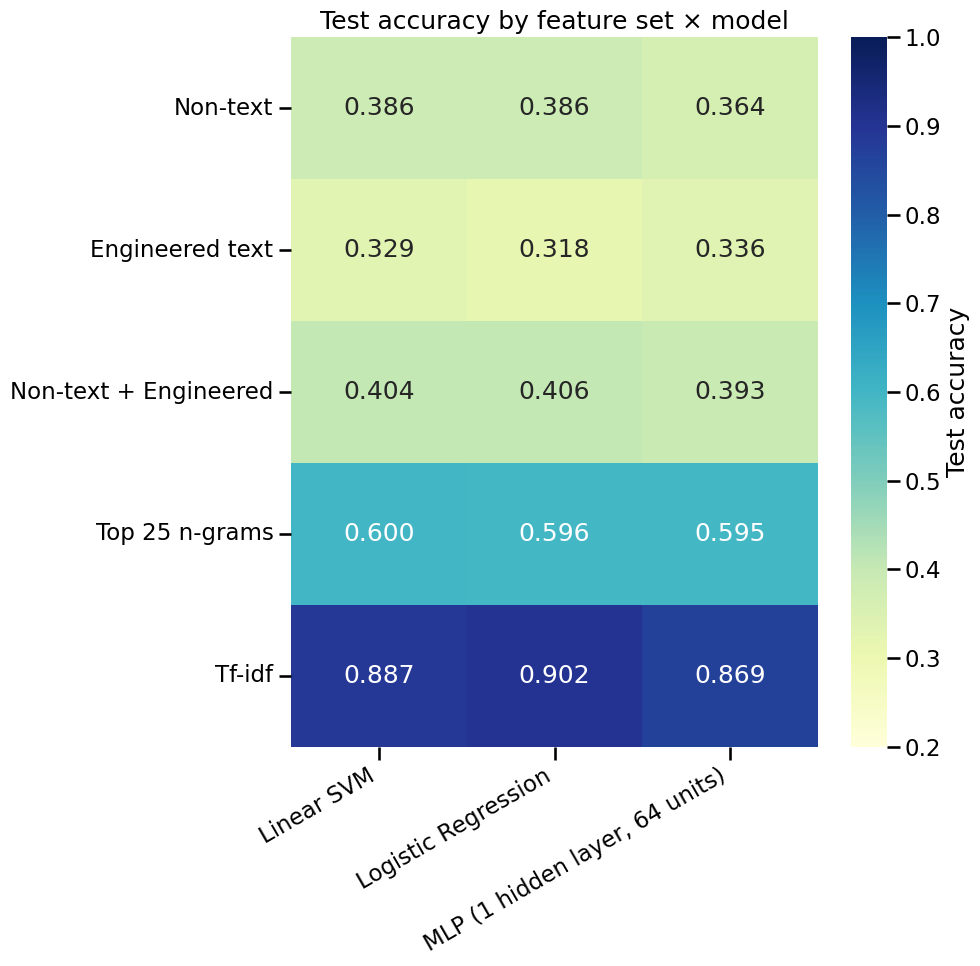

In [17]:
pivot = results_df.pivot(index='features', columns='model', values='accuracy')

row_order = ['Non-text', 'Engineered text', 'Non-text + Engineered',
             'Top 25 n-grams', 'Tf-idf']
pivot = pivot.loc[row_order]

plt.figure(figsize=(10, 10))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0.2, vmax=1.0, cbar_kws={'label': 'Test accuracy'})
plt.title('Test accuracy by feature set × model')
plt.ylabel('')
plt.xlabel('')
plt.xticks(rotation=30, ha='right')   
plt.tight_layout()
plt.show()


### What the table tells us

1. Non-text metadata alone is around 35% — slightly above the 25% baseline.
2. Engineered text features (length, sentiment) are still weak — even slightly weaker than non-text alone.
3. Non-text + engineered combined does a bit better than either one on its own, but still well under 50%.
4. Tf-idf is the big jump. Once the model can see the actual words, accuracy lands well above 90%.
5. The top-25 n-grams sit in between — much more compact than tf-idf, but a lot of vocabulary thrown away.


# Inspect the best model

Let's take a closer look at the best single combination — usually Logistic Regression on tf-idf — and see *what* it gets wrong and *why*.

In [18]:
best = (results_df.sort_values('accuracy', ascending=False).iloc[0])
print("Best combination:")
print(best)

best_feat = best['features']
best_model_name = best['model']
Xtr, Xte = feature_sets[best_feat]
best_pipe = make_models()[best_model_name].fit(Xtr, y_train)
y_pred = best_pipe.predict(Xte)


Best combination:
features                 Tf-idf
model       Logistic Regression
accuracy                 0.9025
Name: 9, dtype: object


## Classification report

`precision` = of the predictions for class C, what fraction were correct.
`recall`    = of the actual class-C examples, what fraction did we catch.
`f1-score`  = harmonic mean of precision and recall.

<img src='./images/f1.png' alt="svm" width="400">


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=le.classes_))


                             precision    recall  f1-score   support

Credit card or prepaid card       0.88      0.92      0.90       200
            Debt collection       0.86      0.88      0.87       200
                   Mortgage       0.95      0.91      0.93       200
               Student loan       0.92      0.91      0.92       200

                   accuracy                           0.90       800
                  macro avg       0.90      0.90      0.90       800
               weighted avg       0.90      0.90      0.90       800



## Confusion matrix

Rows are the *true* class, columns are the *predicted* class. The diagonal is correct predictions; off-diagonals are confusions.

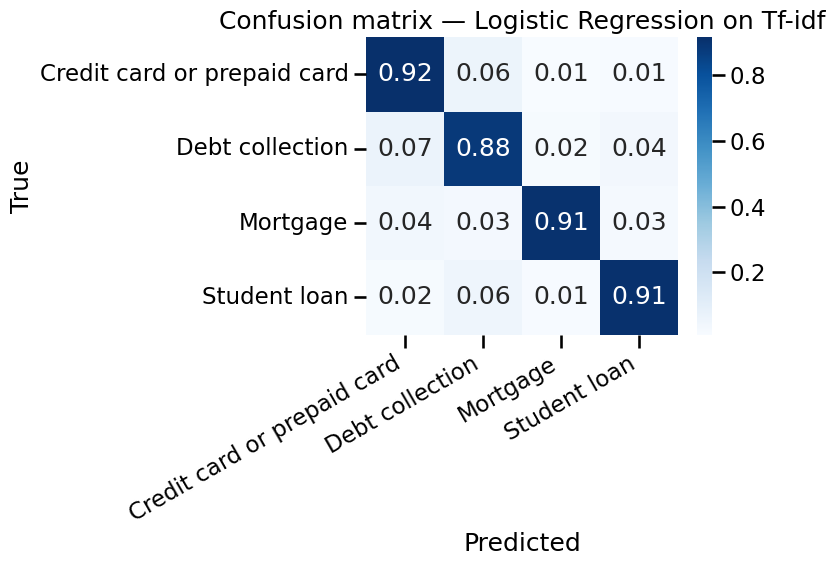

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion matrix — {best_model_name} on {best_feat}')
plt.xticks(rotation=30, ha='right')   
plt.tight_layout()
plt.show()


## Which words drive each prediction?

For a linear model on tf-idf, the coefficients tell us exactly which tokens push the prediction toward each class. We look at the top positive coefficients per class.

In [21]:
# Only works for the linear models (Logistic Regression, LinearSVC).
clf = best_pipe.named_steps['clf']
if hasattr(clf, 'coef_') and best_feat == 'Tf-idf':
    terms = np.array(tfidf_vec.get_feature_names_out())
    coefs = clf.coef_   # shape: (n_classes, n_features)

    n_top = 12
    for cls_idx, cls_name in enumerate(le.classes_):
        top_idx = np.argsort(coefs[cls_idx])[::-1][:n_top]
        print(f"\n{cls_name}:")
        for i in top_idx:
            print(f"  {terms[i]:25s}  {coefs[cls_idx, i]:+.3f}")
else:
    print("Top-coefficients view skipped — best model is not linear on tf-idf.")



Credit card or prepaid card:
  card                       +4.157
  late                       +1.642
  capital                    +1.536
  credit                     +1.336
  charges                    +1.267
  bank                       +1.202
  citi                       +1.099
  account                    +1.093
  express                    +1.054
  chase                      +1.024
  close                      +1.002
  synchrony                  +0.996

Debt collection:
  debt                       +2.692
  collection                 +2.684
  collect                    +1.269
  calls                      +1.198
  company                    +1.144
  collections                +1.112
  collector                  +1.085
  owe                        +0.985
  agency                     +0.900
  lived                      +0.848
  removed                    +0.805
  recovery                   +0.801

Mortgage:
  mortgage                   +5.334
  escrow                     +1.912
  hom

# A few takeaway

### Features matter more than algorithms (usually)

The gap between Logistic Regression, Linear SVM, and a small MLP on the *same* features is small — a few percentage points. The gap between non-text features and tf-idf features is huge — tens of percentage points. 

### More features is not always better

Stacking everything together does not automatically win. Noisy features can drag a model down, especially on small datasets, and high-cardinality categoricals can cause overfitting. 

### Watch for leakage

Anything that summarizes statistics of the data (`TfidfVectorizer`, `CountVectorizer`, `StandardScaler`) must be fit on the training set only. If you fit on the full dataset before splitting, your test accuracy will be too optimistic.

### Accuracy is not the only metric

With balanced classes here, accuracy is reasonable, but in many real applications classes are imbalanced and a model that always predicts the majority class can have high accuracy and zero recall on the minority class. Always look at the classification report and confusion matrix.



# Advanced: Finetuning BERT for classfication

In [22]:
# !pip install datasets
# !pip install accelerate

In [23]:
from datasets import Dataset

def make_hf_dataset(idx, labels):
    return Dataset.from_dict({
        'text':  cfpb.loc[idx, 'Consumer complaint narrative'].tolist(),
        'label': labels.tolist(),
    })

train_ds = make_hf_dataset(train_idx, y_train)
test_ds  = make_hf_dataset(test_idx,  y_test)

print(train_ds)
print(test_ds)


Dataset({
    features: ['text', 'label'],
    num_rows: 3200
})
Dataset({
    features: ['text', 'label'],
    num_rows: 800
})


In [24]:
# Tokenization
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=256,         # CFPB 민원이 길어서 256 정도가 적당
    )

train_ds = train_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# Trainer는 PyTorch 텐서를 기대함
train_ds.set_format('torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format('torch',  columns=['input_ids', 'attention_mask', 'label'])


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [25]:
# load model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4,
    id2label={i: name for i, name in enumerate(le.classes_)},
    label2id={name: i for i, name in enumerate(le.classes_)},
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [26]:
# train model
import numpy as np
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1_macro': f1_score(labels, preds, average='macro'),
    }

args = TrainingArguments(
    output_dir='../bert_cfpb_out',
    num_train_epochs=2,                
    per_device_train_batch_size=16,    
    per_device_eval_batch_size=32,
    learning_rate=2e-5,                
    eval_strategy='epoch',
    logging_steps=50,
    save_strategy='no',                
    report_to='none',                  
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    compute_metrics=compute_metrics,
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.369400,0.337566,0.892500,0.893065
2,0.264873,0.296602,0.902500,0.903008


TrainOutput(global_step=400, training_loss=0.4796075081825256, metrics={'train_runtime': 184.9916, 'train_samples_per_second': 34.596, 'train_steps_per_second': 2.162, 'total_flos': 423910794854400.0, 'train_loss': 0.4796075081825256, 'epoch': 2.0})

In [27]:
# evaluate
eval_result = trainer.evaluate()
print(eval_result)

Training Loss,Validation Loss,Epoch,Accuracy,F1 Macro
0.264873,0.296602,2,0.902500,0.903008


{'eval_loss': 0.2966018617153168, 'eval_accuracy': 0.9025, 'eval_f1_macro': 0.9030082990188603}


In [28]:
# compare
bert_acc = eval_result['eval_accuracy']

results_df_with_bert = pd.concat([
    results_df,
    pd.DataFrame([{
        'features': 'Raw text (BERT tokens)',
        'model':    'Fine-tuned DistilBERT',
        'accuracy': bert_acc,
    }])
], ignore_index=True)

results_df_with_bert.sort_values('accuracy', ascending=False)


,features,model,accuracy
9,Tf-idf,Logistic Regression,0.90250
15,Raw text (BERT tokens),Fine-tuned DistilBERT,0.90250
10,Tf-idf,Linear SVM,0.88750
11,Tf-idf,"MLP (1 hidden layer, 64 units)",0.86875
13,Top 25 n-grams,Linear SVM,0.60000
12,Top 25 n-grams,Logistic Regression,0.59625
14,Top 25 n-grams,"MLP (1 hidden layer, 64 units)",0.59500
6,Non-text + Engineered,Logistic Regression,0.40625
7,Non-text + Engineered,Linear SVM,0.40375
8,Non-text + Engineered,"MLP (1 hidden layer, 64 units)",0.39250
